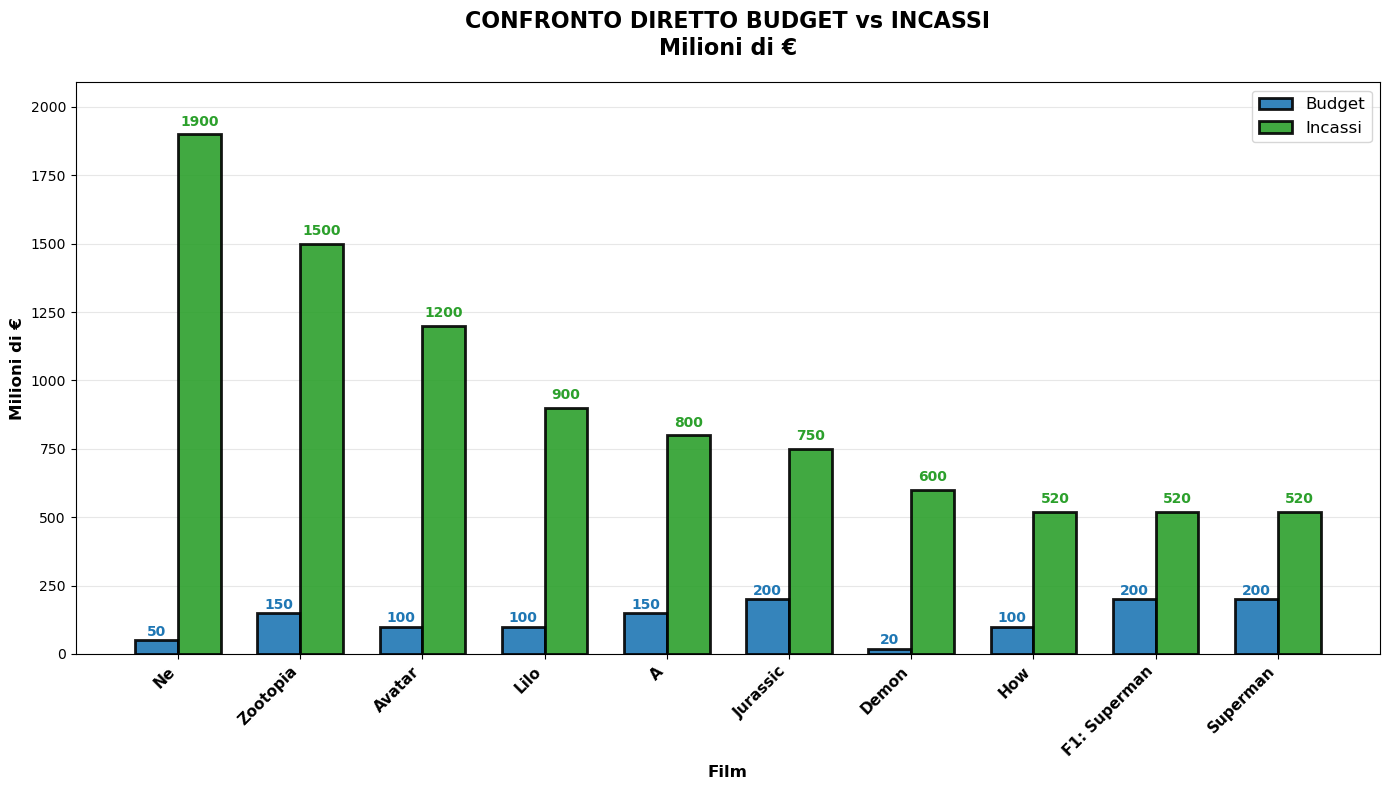

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Caricamento dei dati
incassi_df = pd.read_csv('IncassiTot.csv', thousands=',')
budget_df = pd.read_csv('Budget.csv')

# Pulizia dei dati incassi
incassi_df.columns = incassi_df.columns.str.strip()
incassi_df = incassi_df[['Nome del film', 'Incassi (in euro)']]
incassi_df['Incassi (milioni €)'] = incassi_df['Incassi (in euro)'] / 1_000_000

# Dati budget dall'immagine (valori precisi)
valori_budget = {
    'Ne Zha 2': 50,
    'Zootopia 2': 150,
    'Avatar: Fire and Ash': 100,
    'Lilo & Stitch': 100,
    'A Minecraft Movie': 150,
    'Jurassic World: Rebirth': 200,
    'Demon Slayer': 20,
    'How to Train Your Dragon': 100,
    'F1: The Movie': 200,
    'Superman': 200
}

# Dati incassi dall'immagine (arrotondati)
valori_incassi = {
    'Ne Zha 2': 1900,
    'Zootopia 2': 1500,
    'Avatar: Fire and Ash': 1200,
    'Lilo & Stitch': 900,
    'A Minecraft Movie': 800,
    'Jurassic World: Rebirth': 750,
    'Demon Slayer': 600,
    'How to Train Your Dragon': 520,
    'F1: The Movie': 520,
    'Superman': 520
}

# Crea DataFrame con i valori dall'immagine
films = list(valori_budget.keys())
budget = list(valori_budget.values())
incassi = list(valori_incassi.values())

# Nomi abbreviati come nell'immagine
nomi_abbreviati = ['Ne', 'Zootopia', 'Avatar', 'Lilo', 'A', 'Jurassic', 'Demon', 'How', 'F1: Superman', 'Superman']

# Crea il grafico
plt.figure(figsize=(14, 8))

# Posizioni delle barre
x = np.arange(len(films))
width = 0.35

# Crea le barre del Budget (blu)
bars_budget = plt.bar(x - width/2, budget, width,
                      label='Budget',
                      color='#1f77b4',  # Blu
                      alpha=0.9,
                      edgecolor='black',
                      linewidth=2)

# Crea le barre degli Incassi (verde)
bars_incassi = plt.bar(x + width/2, incassi, width,
                       label='Incassi',
                       color='#2ca02c',  # Verde
                       alpha=0.9,
                       edgecolor='black',
                       linewidth=2)

# Aggiungi valori sulle barre del Budget
for bar in bars_budget:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{height:.0f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold',
             color='#1f77b4')

# Aggiungi valori sulle barre degli Incassi
for bar in bars_incassi:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'{height:.0f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold',
             color='#2ca02c')

# Configura il grafico
plt.xlabel('Film', fontsize=12, fontweight='bold')
plt.ylabel('Milioni di €', fontsize=12, fontweight='bold')
plt.title('CONFRONTO DIRETTO BUDGET vs INCASSI\nMilioni di €', 
          fontsize=16, fontweight='bold', pad=20)

# Imposta le etichette sull'asse x (nomi abbreviati)
plt.xticks(x, nomi_abbreviati, rotation=45, ha='right', fontsize=11, fontweight='bold')

# Legenda
plt.legend(fontsize=12, loc='upper right')

# Griglia
plt.grid(True, alpha=0.3, axis='y')
plt.gca().set_axisbelow(True)

# Imposta limiti dell'asse y
plt.ylim(0, max(incassi) * 1.1)

plt.tight_layout()
plt.show()